In [3]:
import json
import re
import os
import hashlib
import numpy as np
import pandas as pd
import warnings
import copy
from collections import Counter
from difflib import SequenceMatcher
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# =============================================================================
# CONFIGURATION & PATHS
# =============================================================================
base_dir = "../HUGO-CS/Dataset/AlternateVersions/"

dataset_path   = f"{base_dir}Extracted-6-10-25.json"
gt_path        = f"{base_dir}Extracted-6-10-25_gt.json"
remapped_path  = f"{base_dir}Extracted-6-10-25_gt_remapped.json"
deleted_path   = f"{base_dir}Extracted-6-10-25_gt_remapped_swapped_deleted.json"
grouped_path   = f"{base_dir}Extracted-6-10-25_gt_remapped_swapped_deleted_filled_sorted_powderClass_grouped.json"
imputed_path   = f"{base_dir}Extracted-6-10-25_gt_remapped_swapped_deleted_filled_sorted_powderClass_grouped_imputed.json"
blended_path   = f"{base_dir}Extracted-6-10-25_gt_remapped_swapped_deleted_filled_sorted_powderClass_grouped_imputed_blended.json"

template_path  = "../HUGO-CS/GroundTruth/HRM_Flagged/Template6_11_2025.json"
replace_json   = "../HUGO-CS/prompts/regExReplace2.json"

GT_FLAGS = {"Ground Truth", "Ground Truth (Validation)"}

# =============================================================================
# PART 1: HELPER FUNCTIONS
# =============================================================================

def compute_iou(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    intersection = set_a & set_b
    union = set_a | set_b
    return len(intersection) / len(union)

# Hardness tables (omitted for brevity, assume standard definitions remain)
_HRC_POINTS = np.array([68,67,66,65,64,63,62,61,60,59,58,57,56,55,54,53,52,51,50,49,48,47,46])
_HV_FROM_HRC = np.array([940,900,865,832,800,772,746,720,697,674,653,633,613,595,577,560,544,528,513,498,484,471,458])
_HRA_POINTS = np.array([85.6,85.0,84.5,83.9,83.4,82.8,82.3,81.8,81.2,80.7,80.1,79.6,79.0,78.5,78.0,77.4,76.8,76.3,75.9,75.2,74.4,74.1,73.6])
_HV_FROM_HRA = _HV_FROM_HRC.copy()
_HRB_POINTS = np.array([
    100,99,98,97,96,95,94,93,92,91,90,89,88,87,86,85,84,83,82,81,
    80,79,78,77,76,75,74,73,72,71,70,69,68,67,66,65,64,63,62,61,60
])
_HV_FROM_HRB = np.array([
    240,234,228,222,216,210,205,200,195,190,185,180,176,172,169,165,162,159,156,153,
    150,147,144,141,139,137,135,132,130,127,125,123,121,119,117,116,114,112,110,108,107
])

def hrb_to_hv(x): return float(np.interp(x, _HRB_POINTS, _HV_FROM_HRB))
def hrc_to_hv(x): return float(np.interp(x, _HRC_POINTS, _HV_FROM_HRC))
def hra_to_hv(x): return float(np.interp(x, _HRA_POINTS, _HV_FROM_HRA))

def convert_unit(val, unit):
    u = (unit or '').strip().lower()
    dist = {'µm':1,'um':1,'mm':1e3,'cm':1e4,'m':1e6}
    if u in dist: return val * dist[u]
    if u in ('c','°c','celsius'): return val
    if u in ('k','kelvin'): return val - 273.15
    if u in ('f','°f','fahrenheit'): return (val - 32)*5/9
    pmap = {'mpa':1.0,'gpa':1e3}
    if u in pmap: return val * pmap[u]
    return val

def to_hv(raw_val, unit):
    u = (unit or '').strip().lower()
    if u in ('hv','vickers'): return raw_val
    if u in ('mpa','gpa'):
        mpa = raw_val * (1e3 if u=='gpa' else 1.0)
        return mpa / 9.807
    if u in ('hrb','rockwell b'): return hrb_to_hv(raw_val)
    if u in ('hrc','rockwell c'): return hrc_to_hv(raw_val)
    if u in ('hra','rockwell a'): return hra_to_hv(raw_val)
    return raw_val

num_re = re.compile(r'^([0-9.]+)')

# Function definition kept for reference (commented out in execution)
def remapping_keys(input_path: str, output_path: str, template_path: str) -> None:
    pass

# =============================================================================
# PART 2: LOAD DATASETS
# =============================================================================

with open(dataset_path, "r", encoding="utf-8") as f: pre_docs = json.load(f)
with open(gt_path, "r", encoding="utf-8") as f: gt_docs = json.load(f)
with open(remapped_path, "r", encoding="utf-8") as f: remapped_docs = json.load(f)
with open(deleted_path, "r", encoding="utf-8") as f: deleted_docs = json.load(f)
with open(grouped_path, "r", encoding="utf-8") as f: grouped_docs = json.load(f)
with open(imputed_path, "r", encoding="utf-8") as f: imputed_docs = json.load(f)
with open(blended_path, "r", encoding="utf-8") as f: blended_docs = json.load(f)

# =============================================================================
# PART 3: STAGE CALCULATION (Bucket Assignment)
# =============================================================================

llm_value_field = {
    "porosity": "Porosity_Value",
    "elongation": "Elongation_at_Break_Value",
    "modulus": "Elastic_Modulus_Value",
    "ultimate_tensile_strength": "Ultimate_Tensile_Strength_Value",
    "yield_strength": "Yield_Strength_Value",
    "microhardness": "Deposit_Microhardness_Value",
    "nanohardness": "Deposit_Nanohardness_Value",
    "deposition_efficiency": "Deposition_Efficiency_Value",
}
MISSING_THRESHOLD = 1.0
metrics = list(llm_value_field.keys())

# V(D) Calculation
cat2 = [d for d in pre_docs if d.get("data_category") == 2 and d.get("properties_reported_in_figures")]
R_global = {m: 0 for m in metrics}
per_doc  = {}
for d in cat2:
    fname = d.get("filename", "<unknown>")
    E     = d.get("num_expected_experiments_in_figures", 0)
    M     = [m for m in d["properties_reported_in_figures"] if m in metrics]
    ext   = d.get("extractedText", {})
    exps  = ext.get("Experiments") if isinstance(ext, dict) else None
    X = {}
    for m in M:
        field = llm_value_field[m]
        if isinstance(exps, list):
            r = sum(1 for exp in exps if exp.get("resultsValues", {}).get(field, "") not in (None, "", []))
        else:
            r = 0
        X[m] = max(0, E - r)
        R_global[m] += r
    per_doc[fname] = {"X": X, "M": M}

inv     = {m: (1.0 / R_global[m]) if R_global[m] > 0 else 0.0 for m in metrics}
sum_inv = sum(inv.values())
w       = {m: (inv[m] / sum_inv) if sum_inv > 0 else 0.0 for m in metrics}
V_map   = {fname: sum(w[m] * info["X"][m] for m in info["M"]) for fname, info in per_doc.items()}

# Stage Assignment
with open(template_path, 'r', encoding='utf-8') as f:
    template = json.load(f)
template_exp  = template["Experiments"][0]
sections      = ["preSprayedProperties", "experimentalProperties", "resultsValues"]
template_keys = {sec: set(template_exp.get(sec, {})) for sec in sections}

records = []
for doc in pre_docs:
    filename = doc.get("filename", "<unknown>")
    ext = doc.get("extractedText")
    
    missing_pruned = isinstance(ext, str) and ("Pruned" not in ext)
    missing_expts  = isinstance(ext, dict) and ("Experiments" not in ext)
    stage2A_incomplete = (missing_pruned or missing_expts)

    exps = doc.get("Experiments")
    if not isinstance(exps, list) and isinstance(ext, dict):
        exps = ext.get("Experiments")

    mean_doc_iou    = None
    stage2B_low_iou = False
    if isinstance(exps, list) and exps:
        exp_ious = []
        for exp in exps:
            if not isinstance(exp, dict): continue
            per_sec = []
            for sec in sections:
                val      = exp.get(sec)
                rep_keys = set(val.keys()) if isinstance(val, dict) else set()
                per_sec.append(compute_iou(template_keys[sec], rep_keys))
            if per_sec:
                exp_ious.append(sum(per_sec) / len(per_sec))
        if exp_ious:
            mean_doc_iou    = sum(exp_ious) / len(exp_ious)
            stage2B_low_iou = (mean_doc_iou < 0.15)

    stage2A_immediate_hand = (stage2A_incomplete)
    gt_source = (doc.get("InformationSource") == "Ground Truth")
    stage3A_datafigure_lvl3 = (doc.get("data_category") == 3) and not gt_source
    Vd = V_map.get(filename, 0.0)
    stage3B_datafigure_lvl2upper = (Vd > MISSING_THRESHOLD) and not gt_source
    stage3 = (stage3A_datafigure_lvl3 or stage3B_datafigure_lvl2upper) and not gt_source
    stage4A_missing = (mean_doc_iou is not None and mean_doc_iou < 1.0)

    stage4B_unfilled = False
    if isinstance(exps, list):
        for exp in exps:
            if not isinstance(exp, dict): continue
            for sec in sections:
                val = exp.get(sec)
                if isinstance(val, dict):
                    for key, v in val.items():
                        if "Binary" in key and v == "":
                            stage4B_unfilled = True
                            break
                    if stage4B_unfilled: break
            if stage4B_unfilled: break

    stage4_llm_incorrect = (stage4A_missing or stage4B_unfilled)

    records.append({
        "filename": filename,
        "Stage2A_ImmediateHandLabel": stage2A_immediate_hand,
        "Stage3_FigureInfoPresent": stage3,
        "Stage4_LLMIncorrect": stage4_llm_incorrect,
    })

df = pd.DataFrame(records)

# Outlier Detection (Stage 5)
with open(replace_json, 'r') as f:
    material_map = json.load(f)['materialNamingConventions']
lower_map = {k.lower(): v for k, v in material_map.items()}
def normalize_material(name):
    name = (name or '').strip()
    return lower_map.get(name.lower(), name)

all_exps = []
for art in pre_docs:
    fn = art.get('filename','<unknown>')
    ext = art.get('extractedText', {})
    if isinstance(ext, str):
        try: ext = json.loads(ext)
        except: ext = {}
    exps = []
    if isinstance(ext, dict): exps = ext.get('Experiments', [])
    elif isinstance(ext, list):
        for item in ext:
            if isinstance(item, dict) and 'Experiments' in item:
                exps.extend(item['Experiments'])
    for exp in exps:
        if not isinstance(exp, dict): continue
        pre = exp.get('preSprayedProperties', {})
        parts = []
        for key in ('Majority_Powder_Material_Name','Secondary_Powder_Material_Name','Tertiary_Powder_Material_Name'):
            nm = normalize_material(pre.get(key, ''))
            if nm and nm != '[V] Not Reported': parts.append(nm)
            pre[key] = nm
        if parts and all(p.startswith('[V]') for p in parts):
            exp['material_class'] = " / ".join(parts)
            all_exps.append((fn, exp))

counts = Counter(cls for _, exp in all_exps for cls in [exp['material_class']])
valid_classes = {cls for cls, cnt in counts.items() if cnt >= 3}
filtered_exps = [(fn, e) for fn, e in all_exps if e['material_class'] in valid_classes]

NUM_KEYS = ["Porosity_Value","Elastic_Modulus_Value","Yield_Strength_Value",
            "Ultimate_Tensile_Strength_Value","Elongation_at_Break_Value",
            "Deposit_Microhardness_Value","Deposit_Nanohardness_Value",
            "Deposition_Efficiency_Value"]
rows_tsne = []
for filename, e in filtered_exps:
    cls = e['material_class']
    res = e.get('resultsValues', {})
    numerics = {}
    for k in NUM_KEYS:
        raw = res.get(k, "")
        if isinstance(raw, (int, float)): v = float(raw)
        else:
            m = num_re.match(str(raw).strip())
            v = float(m.group(1)) if m else np.nan
        unit = res.get(k.replace('_Value','_Units'), "").strip()
        base = convert_unit(v, unit)
        if k == "Deposition_Efficiency_Value" and not unit and base < 1: base *= 100
        if 'hardness' in k.lower(): numerics[k] = to_hv(v, unit)
        else: numerics[k] = base
    rows_tsne.append({'filename': filename, 'class': cls, **numerics})

df_full = pd.DataFrame(rows_tsne)
outlier_files = set()
if not df_full.empty:
    def fill_med_zero(grp): return grp.fillna(grp.median()) if not grp.dropna().empty else grp.fillna(0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        df_full[NUM_KEYS] = df_full.groupby('class')[NUM_KEYS].transform(fill_med_zero)
    df_full[NUM_KEYS] = df_full[NUM_KEYS].fillna(0)
    X_num = StandardScaler().fit_transform(df_full[NUM_KEYS])
    coords = TSNE(n_components=2, random_state=42, init='pca').fit_transform(X_num)
    df_plot = pd.DataFrame({'TSNE1': coords[:,0], 'TSNE2': coords[:,1], 'class': df_full['class'], 'filename': df_full['filename']})
    df_plot['c1'] = df_plot.groupby('class')['TSNE1'].transform('mean')
    df_plot['c2'] = df_plot.groupby('class')['TSNE2'].transform('mean')
    df_plot['distance'] = np.sqrt((df_plot['TSNE1']-df_plot['c1'])**2 + (df_plot['TSNE2']-df_plot['c2'])**2)
    def flag_group_outliers(dist):
        n = len(dist)
        if n >= 50: return dist > (dist.mean() + 2*dist.std())
        if n >= 10:
            med = np.median(dist)
            mad = np.median(np.abs(dist - med))
            return dist > (med + 3*mad)
        return np.zeros(n, dtype=bool)
    df_plot['is_outlier'] = df_plot.groupby('class')['distance'].transform(lambda d: flag_group_outliers(d.values))
    outlier_files = set(df_plot[df_plot['is_outlier']]['filename'])

df['Stage5_Outlier'] = (df['filename'].isin(outlier_files) & ~df['Stage2A_ImmediateHandLabel'] & ~df['Stage3_FigureInfoPresent'])
df['AssignedStage'] = np.select(
    [df['Stage2A_ImmediateHandLabel'], df['Stage3_FigureInfoPresent'], df['Stage4_LLMIncorrect'], df['Stage5_Outlier']],
    ['Stage2', 'Stage3', 'Stage4', 'Stage5'],
    default='None'
)

# =============================================================================
# PART 4: DIFFERENTIAL COUNTING
# =============================================================================

def _stable_json(obj):
    return json.dumps(obj, sort_keys=True, ensure_ascii=False, default=str, separators=(",", ":"))
def _hash(obj):
    return hashlib.sha256(_stable_json(obj).encode("utf-8")).hexdigest()
def _basename(doc):
    fn = (doc or {}).get("filename", "")
    return os.path.basename(fn) if isinstance(fn, str) else ""
def _get_experiments(doc):
    if not isinstance(doc, dict): return []
    ext = doc.get("extractedText", {})
    if isinstance(ext, str):
        try: ext = json.loads(ext)
        except: ext = {}
    if not isinstance(ext, dict): return []
    exps = ext.get("Experiments", [])
    if not isinstance(exps, list): return []
    return [e for e in exps if isinstance(e, dict)]
def _count_nonzero_articles_and_exps(docs):
    n_articles = 0
    n_exps = 0
    for d in docs:
        exps = _get_experiments(d)
        if len(exps) > 0: n_articles += 1; n_exps += len(exps)
    return n_articles, n_exps

pre_map = { _basename(d): d for d in pre_docs if _basename(d)}
gt_map  = { _basename(d): d for d in gt_docs if _basename(d)}
remap_map = { _basename(d): d for d in remapped_docs if _basename(d)}
del_map = { _basename(d): d for d in deleted_docs if _basename(d)}
grouped_map = { _basename(d): d for d in grouped_docs if _basename(d)}
imputed_map = { _basename(d): d for d in imputed_docs if _basename(d)}
blended_map = { _basename(d): d for d in blended_docs if _basename(d)}

stage_map = {}
try:
    _tmp = df.copy()
    _tmp["filename"] = _tmp["filename"].astype(str).map(os.path.basename)
    stage_map = dict(zip(_tmp["filename"], _tmp["AssignedStage"]))
except: stage_map = {}
def _stage_for_filename(fn_base):
    s = stage_map.get(fn_base, "None")
    return s if s in {"Stage2","Stage3","Stage4","Stage5"} else "None"

# --- A) GT Corrections (Stages 2..None) ---
rows_gt_diff = []
for fn, gt_doc in gt_map.items():
    info_src = (gt_doc.get("InformationSource") or "").strip()
    if info_src not in GT_FLAGS: continue
    pre_doc = pre_map.get(fn, None)
    old_exps = _get_experiments(pre_doc) if pre_doc else []
    new_exps = _get_experiments(gt_doc)
    old_len, new_len = len(old_exps), len(new_exps)
    shared = min(old_len, new_len)
    exp_modified = 0
    exp_verified = 0
    for i in range(shared):
        if _hash(old_exps[i]) == _hash(new_exps[i]): exp_verified += 1
        else: exp_modified += 1
    stage_key = "Validation" if info_src == "Ground Truth (Validation)" else _stage_for_filename(fn)

    rows_gt_diff.append({
        "stage": stage_key,
        "a_add": int(old_len == 0 and new_len > 0),
        "a_del": int(old_len > 0 and new_len == 0),
        "a_mv":  int((not (old_len == 0 and new_len > 0)) and (not (old_len > 0 and new_len == 0))),
        "e_add": int(max(0, new_len - old_len)),
        "e_rem": int(max(0, old_len - new_len)),
        "e_mv":  int(exp_modified + exp_verified)
    })
gt_by_stage = pd.DataFrame(rows_gt_diff)

# --- B) Empty Result Removal (Remapped -> Deleted) ---
a_add_del, a_del_del, a_mv_del, e_add_del, e_rem_del, e_mv_del = 0,0,0,0,0,0
all_keys_del = set(remap_map.keys()) | set(del_map.keys())
for fn in all_keys_del:
    doc_in = remap_map.get(fn)
    doc_out = del_map.get(fn)
    old_exps = _get_experiments(doc_in) if doc_in else []
    new_exps = _get_experiments(doc_out) if doc_out else []
    if len(old_exps) == len(new_exps): continue 
    is_add = (len(old_exps) == 0 and len(new_exps) > 0)
    is_del = (len(old_exps) > 0 and len(new_exps) == 0)
    is_mv  = (not is_add) and (not is_del)
    a_add_del += int(is_add)
    a_del_del += int(is_del)
    a_mv_del  += int(is_mv)
    e_add_del += max(0, len(new_exps) - len(old_exps))
    e_rem_del += max(0, len(old_exps) - len(new_exps))

# --- C) Key Realignment (GT -> Remapped) ---
a_add_rm, a_del_rm, a_mv_rm, e_add_rm, e_rem_rm, e_mv_rm = 0,0,0,0,0,0
all_keys_rm = set(gt_map.keys()) | set(remap_map.keys())
for fn in all_keys_rm:
    doc_in = gt_map.get(fn)
    doc_out = remap_map.get(fn)
    if not doc_in or not doc_out: continue 
    old_exps = _get_experiments(doc_in)
    new_exps = _get_experiments(doc_out)
    old_len, new_len = len(old_exps), len(new_exps)
    shared = min(old_len, new_len)
    modified_exps = 0
    for i in range(shared):
        if _hash(old_exps[i]) != _hash(new_exps[i]):
            modified_exps += 1
    if modified_exps > 0:
        a_mv_rm += 1
        e_mv_rm += modified_exps

# --- D) Categorical String Mapping & Continuous Composition Mapping ---
cat_a_mv, cat_e_mv = 0, 0
cont_a_mv, cont_e_mv = 0, 0
comp_keys = ["Majority_Powder_Chemical_Composition", "Secondary_Powder_Chemical_Composition", "Tertiary_Powder_Chemical_Composition"]

for doc in grouped_docs:
    exps = _get_experiments(doc)
    doc_cat_hit, doc_cont_hit = False, False
    cnt_cat_exps, cnt_cont_exps = 0, 0
    
    for exp in exps:
        has_bracket_v = False
        def check_v(obj):
            if isinstance(obj, dict): return any(check_v(v) for v in obj.values())
            if isinstance(obj, list): return any(check_v(v) for v in obj)
            if isinstance(obj, str): return obj.strip().startswith("[V]")
            return False
        if check_v(exp): has_bracket_v = True
            
        has_json_comp = False
        for sec in ["preSprayedProperties", "experimentalProperties", "resultsValues"]:
            props = exp.get(sec, {})
            if not isinstance(props, dict): continue
            for k, v in props.items():
                if k in comp_keys and isinstance(v, str) and v.strip().startswith("{"):
                    try:
                        json.loads(v)
                        has_json_comp = True
                    except: pass
        
        if has_bracket_v: cnt_cat_exps += 1; doc_cat_hit = True
        if has_json_comp: cnt_cont_exps += 1; doc_cont_hit = True

    if doc_cat_hit: cat_a_mv += 1
    cat_e_mv += cnt_cat_exps
    if doc_cont_hit: cont_a_mv += 1
    cont_e_mv += cnt_cont_exps

# --- E) Known Composition Imputation ---
imp_a_mv, imp_e_mv = 0, 0
for fn, doc_imputed in imputed_map.items():
    doc_grouped = grouped_map.get(fn)
    if not doc_grouped: continue
    exps_imp = _get_experiments(doc_imputed)
    exps_grp = _get_experiments(doc_grouped)
    limit = min(len(exps_imp), len(exps_grp))
    cnt_imp_exps = 0
    doc_imp_hit = False
    
    for i in range(limit):
        e_imp = exps_imp[i]
        e_grp = exps_grp[i]
        def get_comp_vals(exp_obj):
            vals = {}
            for sec in ["preSprayedProperties", "experimentalProperties", "resultsValues"]:
                p = exp_obj.get(sec, {})
                if isinstance(p, dict):
                    for k in comp_keys:
                        if k in p: vals[k] = p[k]
            return vals
        imp_vals = get_comp_vals(e_imp)
        grp_vals = get_comp_vals(e_grp)
        was_imputed = False
        for k, v_imp in imp_vals.items():
            v_grp = grp_vals.get(k, "")
            is_json_imp = isinstance(v_imp, str) and v_imp.strip().startswith("{")
            is_json_grp = isinstance(v_grp, str) and v_grp.strip().startswith("{")
            if is_json_imp and not is_json_grp:
                was_imputed = True
                break
        if was_imputed: cnt_imp_exps += 1; doc_imp_hit = True
    if doc_imp_hit: imp_a_mv += 1
    imp_e_mv += cnt_imp_exps

# --- F) Multi-Powder Composition Blending ---
blend_a_mv, blend_e_mv = 0, 0
blend_target_keys = ["Powder_Blend_Atomic_Composition", "Powder_Blend_Ratio_Standardized"]

for doc in blended_docs:
    exps = _get_experiments(doc)
    doc_blend_hit = False
    cnt_blend_exps = 0
    
    for exp in exps:
        # Check criteria: Blend Atomic Comp is JSON AND Ratio Standardized is non-blank
        is_json_blend = False
        is_ratio_valid = False
        
        # Scan all sections
        for sec in ["preSprayedProperties", "experimentalProperties", "resultsValues"]:
            props = exp.get(sec, {})
            if not isinstance(props, dict): continue
            
            val_comp = props.get("Powder_Blend_Atomic_Composition")
            if isinstance(val_comp, str) and val_comp.strip().startswith("{"):
                is_json_blend = True
                
            val_ratio = props.get("Powder_Blend_Ratio_Standardized")
            if val_ratio is not None and str(val_ratio).strip() != "":
                is_ratio_valid = True
        
        if is_json_blend and is_ratio_valid:
            cnt_blend_exps += 1
            doc_blend_hit = True
            
    if doc_blend_hit: blend_a_mv += 1
    blend_e_mv += cnt_blend_exps

# Totals
pre_n, pre_e = _count_nonzero_articles_and_exps(pre_docs)
hybrid_n, hybrid_e = _count_nonzero_articles_and_exps(blended_docs) # Final dataset is now blended
if not gt_by_stage.empty:
    hand_a_add, hand_a_mv, hand_a_del = int(gt_by_stage["a_add"].sum()), int(gt_by_stage["a_mv"].sum()), int(gt_by_stage["a_del"].sum())
    hand_e_add, hand_e_mv, hand_e_rem = int(gt_by_stage["e_add"].sum()), int(gt_by_stage["e_mv"].sum()), int(gt_by_stage["e_rem"].sum())
else:
    hand_a_add = hand_a_mv = hand_a_del = hand_e_add = hand_e_mv = hand_e_rem = 0

# =============================================================================
# PART 5: LATEX GENERATION
# =============================================================================

ROW_CONFIG = [
    {"key": "Baseline",       "label": "Initial LLM Labeling",             "type": "LLM"},
    {"key": "Stage2",         "label": "- Structure Flagging Correction",    "type": "Algorithmic / Manual"},
    {"key": "Stage3",         "label": "- Figure Flagging Correction",       "type": "Algorithmic / Manual"},
    {"key": "Stage4",         "label": "- Completeness Flagging Correction", "type": "Algorithmic / Manual"},
    {"key": "Stage5",         "label": "- Outlier Flagging Correction",      "type": "Algorithmic / Manual"},
    {"key": "None",           "label": "- Other Flagging Correction",        "type": "Manual"},
    {"key": "Validation",     "label": "- Held-Out Validation",              "type": "Manual"},
    {"key": "DeleteStep",     "label": "- Empty Result Removal",             "type": "Algorithmic"},
    {"key": "KeyRealignment", "label": "- Key Realignment",                  "type": "Algorithmic"},
    {"key": "CatMap",         "label": "- Categorical String Mapping",       "type": "Manual / Algorithmic / LLM"},
    {"key": "ContMap",        "label": "- Continuous Composition Mapping",   "type": "Manual / Algorithmic / LLM"},
    {"key": "ImpMap",         "label": "- Known Composition Imputation",     "type": "Manual / Algorithmic / LLM"},
    {"key": "BlendMap",       "label": "- Multi-Powder Composition Blending","type": "Manual / Algorithmic / LLM"},
]

def fmt_plus(x): return f"+{x}" if x != 0 else "0"
def fmt_min(x):  return f"-{x}" if x != 0 else "0"
def fmt_int(x):  return f"{x}"

latex = []
latex.append(r"\begin{table*}[!h]")
latex.append(r"\centering")
latex.append(r"\small")
latex.append(r"\setlength{\tabcolsep}{6pt}")
latex.append(r"\renewcommand{\arraystretch}{1.15}")
latex.append(r"\caption{Overview of hybrid-labeling process per step, highlighting the results of LLM and hand-labeled as a result of automated flagging from incorrect output structures, high-chance of data in figures, missing features, statistical outliers, and other hand-labeled articles.}")
latex.append(r"\label{tab:curation_summary}")
latex.append(r"\begin{adjustbox}{max width=\textwidth}")
latex.append(r"\begin{tabular}{l|c|ccc|ccc}")
latex.append(r"\toprule")
latex.append(r" & & \multicolumn{3}{c|}{\textbf{Articles}} & \multicolumn{3}{c}{\textbf{Experiments}} \\")
latex.append(r"\cmidrule(lr){3-5}\cmidrule(lr){6-8}")
latex.append(r"\textbf{Pipeline Step} & \textbf{Process Type} & \textbf{Added} & \textbf{Modified} & \textbf{Deleted} & \textbf{Added} & \textbf{Modified} & \textbf{Removed} \\")
latex.append(r"\midrule")

for cfg in ROW_CONFIG:
    k = cfg["key"]
    if k == "Baseline":
        latex.append(f"{cfg['label']} & {cfg['type']} & {pre_n} & 0 & 0 & {pre_e} & 0 & 0 \\\\")
    elif k == "KeyRealignment":
        latex.append(f"{cfg['label']} & {cfg['type']} & {fmt_plus(a_add_rm)} & {fmt_int(a_mv_rm)} & {fmt_min(a_del_rm)} & {fmt_plus(e_add_rm)} & {fmt_int(e_mv_rm)} & {fmt_min(e_rem_rm)} \\\\")
    elif k == "DeleteStep":
        latex.append(f"{cfg['label']} & {cfg['type']} & {fmt_plus(a_add_del)} & {fmt_int(a_mv_del)} & {fmt_min(a_del_del)} & {fmt_plus(e_add_del)} & {fmt_int(e_mv_del)} & {fmt_min(e_rem_del)} \\\\")
    elif k == "CatMap":
        latex.append(f"{cfg['label']} & {cfg['type']} & 0 & {fmt_int(cat_a_mv)} & 0 & 0 & {fmt_int(cat_e_mv)} & 0 \\\\")
    elif k == "ContMap":
        latex.append(f"{cfg['label']} & {cfg['type']} & 0 & {fmt_int(cont_a_mv)} & 0 & 0 & {fmt_int(cont_e_mv)} & 0 \\\\")
    elif k == "ImpMap":
        latex.append(f"{cfg['label']} & {cfg['type']} & 0 & {fmt_int(imp_a_mv)} & 0 & 0 & {fmt_int(imp_e_mv)} & 0 \\\\")
    elif k == "BlendMap":
        latex.append(f"{cfg['label']} & {cfg['type']} & 0 & {fmt_int(blend_a_mv)} & 0 & 0 & {fmt_int(blend_e_mv)} & 0 \\\\")
    else:
        sub = gt_by_stage[gt_by_stage["stage"] == k] if not gt_by_stage.empty else None
        if sub is not None:
            aa, am, ad = int(sub["a_add"].sum()), int(sub["a_mv"].sum()), int(sub["a_del"].sum())
            ea, em, er = int(sub["e_add"].sum()), int(sub["e_mv"].sum()), int(sub["e_rem"].sum())
            latex.append(f"{cfg['label']} & {cfg['type']} & {fmt_plus(aa)} & {fmt_int(am)} & {fmt_min(ad)} & {fmt_plus(ea)} & {fmt_int(em)} & {fmt_min(er)} \\\\")
        else:
            latex.append(f"{cfg['label']} & {cfg['type']} & 0 & 0 & 0 & 0 & 0 & 0 \\\\")

latex.append(r"\midrule")
latex.append(f"\\textbf{{LLM-Labeled Dataset Size}} & --- & {pre_n} & --- & --- & {pre_e} & --- & --- \\\\")
latex.append(f"\\textbf{{Hand-Labeled Dataset Size}} & --- & {fmt_plus(hand_a_add)} & {fmt_int(hand_a_mv)} & {fmt_min(hand_a_del)} & {fmt_plus(hand_e_add)} & {fmt_int(hand_e_mv)} & {fmt_min(hand_e_rem)} \\\\")
latex.append(r"\midrule")
latex.append(f"\\textbf{{Hybrid-Labeled Dataset Size}} & --- & {hybrid_n} & --- & --- & {hybrid_e} & --- & --- \\\\")
latex.append(r"\bottomrule")
latex.append(r"\end{tabular}")
latex.append(r"\end{adjustbox}")
latex.append(r"\end{table*}")

print("\n".join(latex))

\begin{table*}[!h]
\centering
\small
\setlength{\tabcolsep}{6pt}
\renewcommand{\arraystretch}{1.15}
\caption{Overview of hybrid-labeling process per step, highlighting the results of LLM and hand-labeled as a result of automated flagging from incorrect output structures, high-chance of data in figures, missing features, statistical outliers, and other hand-labeled articles.}
\label{tab:curation_summary}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{l|c|ccc|ccc}
\toprule
 & & \multicolumn{3}{c|}{\textbf{Articles}} & \multicolumn{3}{c}{\textbf{Experiments}} \\
\cmidrule(lr){3-5}\cmidrule(lr){6-8}
\textbf{Pipeline Step} & \textbf{Process Type} & \textbf{Added} & \textbf{Modified} & \textbf{Deleted} & \textbf{Added} & \textbf{Modified} & \textbf{Removed} \\
\midrule
Initial LLM Labeling & LLM & 1074 & 0 & 0 & 3366 & 0 & 0 \\
- Structure Flagging Correction & Algorithmic / Manual & +33 & 4 & 0 & +261 & 0 & 0 \\
- Figure Flagging Correction & Algorithmic / Manual & +32 & 33 & -4 & 

In [12]:
import json
import re
from typing import Any, Dict, List, Tuple

# -----------------------------
# Config (your exact paths)
# -----------------------------
EXP_JSON_PATH = "../HUGO-CS/Dataset/AlternateVersions/Extracted-6-10-25_gt_remapped_swapped_deleted_filled_sorted.json"
REPLACE_JSON_PATH = "../HUGO-CS/prompts/regExReplace2.json"

# -----------------------------
# Normalization + flattening
# -----------------------------
_WS_RE = re.compile(r"\s+")

def norm_key(s: str) -> str:
    """Case-insensitive, whitespace-normalized key."""
    return _WS_RE.sub(" ", s.strip()).lower()

def safe_load_extracted_text(extracted: Any) -> Any:
    """Handle extractedText being dict, list, or JSON string."""
    if isinstance(extracted, str):
        try:
            return json.loads(extracted)
        except json.JSONDecodeError:
            return {}
    return extracted

def flatten_experiments_from_articles(articles: Any) -> List[Dict[str, Any]]:
    """Flatten Experiments from articles, handling extractedText as dict or list."""
    all_exps: List[Dict[str, Any]] = []
    if not isinstance(articles, list):
        return all_exps

    for art in articles:
        if not isinstance(art, dict):
            continue

        extracted = safe_load_extracted_text(art.get("extractedText", {}))

        exps: List[Any] = []
        if isinstance(extracted, dict):
            exps = extracted.get("Experiments", []) or []
        elif isinstance(extracted, list):
            for item in extracted:
                if isinstance(item, dict):
                    exps.extend(item.get("Experiments", []) or [])

        for exp in exps:
            if isinstance(exp, dict):
                all_exps.append(exp)

    return all_exps

# -----------------------------
# Consolidation summary
# -----------------------------
def _stringify_mapped_value(v: Any) -> str:
    """Stable comparable string for mapped values (dict/list -> deterministic JSON)."""
    if isinstance(v, (dict, list)):
        return json.dumps(v, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    return str(v)

def unique_before_after_consolidation(
    experiments: List[Dict[str, Any]],
    section: str,
    feature: str,
    replace_map: Dict[str, Any],
) -> Dict[str, Any]:
    """
    Counts unique raw string values observed ('before') vs consolidated ('after'):
      consolidated(val) = replace_map[norm(val)] if exists else val
    Only considers string values.
    """
    if not isinstance(replace_map, dict):
        replace_map = {}

    norm_to_repl: Dict[str, Any] = {norm_key(k): v for k, v in replace_map.items()}

    raw_vals: List[str] = []
    consolidated_vals: List[str] = []

    for exp in experiments:
        if not isinstance(exp, dict):
            continue
        props = exp.get(section, {})
        if not isinstance(props, dict):
            continue
        val = props.get(feature)
        if not isinstance(val, str):
            continue

        raw_vals.append(val)

        nk = norm_key(val)
        if nk in norm_to_repl:
            consolidated_vals.append(_stringify_mapped_value(norm_to_repl[nk]))
        else:
            consolidated_vals.append(val)

    unique_before = len(set(raw_vals))
    unique_after = len(set(consolidated_vals))
    pct_red = 0.0 if unique_before == 0 else (unique_before - unique_after) / unique_before * 100.0

    return {
        "section": section,
        "feature": feature,
        "unique_before": unique_before,
        "unique_after": unique_after,
        "percent_reduction": pct_red,
        "n_observations": len(raw_vals),
    }

def print_consolidation_summary(rows: List[Dict[str, Any]]) -> None:
    print("=" * 110)
    print("Unique-value consolidation summary (before vs after mapping)")
    print("=" * 110)

    header = f"{'Variable':<72} {'Before':>8} {'After':>8} {'Reduction':>12}"
    print(header)
    print("-" * len(header))

    for r in rows:
        var = f"{r['section']} -> {r['feature']}"
        before = r["unique_before"]
        after = r["unique_after"]
        red = r["percent_reduction"]
        print(f"{var:<72} {before:>8d} {after:>8d} {red:>11.1f}%")

    print("=" * 110)

# -----------------------------
# LaTeX table (booktabs vibe, with INTERNAL vertical rules only)
# -----------------------------
LATEX_LABELS = {
    ("preSprayedProperties", "Majority_Powder_Material_Name"): "Majority Powder Material",
    ("preSprayedProperties", "Majority_Powder_Primary_Element"): "Majority Powder Primary Element",
    ("preSprayedProperties", "Secondary_Powder_Material_Name"): "Secondary Powder Material",
    ("preSprayedProperties", "Secondary_Powder_Primary_Element"): "Secondary Powder Primary Element",
    ("preSprayedProperties", "Tertiary_Powder_Material_Name"): "Tertiary Powder Material",
    ("preSprayedProperties", "Tertiary_Powder_Primary_Element"): "Tertiary Powder Primary Element",
    ("preSprayedProperties", "Powder_Production_Method"): "Powder Production Method",
    ("experimentalProperties", "Process_Gas_Type"): "Process Gas",
    ("experimentalProperties", "Tensile_Test_Orientation"): "Tensile Test Orientation",
    ("experimentalProperties", "Spraying_System_Model"): "Cold Spray System",
    ("experimentalProperties", "Deposit_Post_Treatment_Description"): "Post-Deposition Treatment",
}

def make_latex_table(summary_rows: List[Dict[str, Any]]) -> str:
    """
    Near-identical formatting to the previous booktabs-style table*,
    but with INTERNAL vertical lines:
      Feature  |  Unique Before  |  Unique After  |  Reduction
    No outer box, no per-row \hline.
    """
    idx = {(r["section"], r["feature"]): r for r in summary_rows}

    order = [
        ("preSprayedProperties", "Majority_Powder_Material_Name"),
        ("preSprayedProperties", "Majority_Powder_Primary_Element"),
        ("preSprayedProperties", "Secondary_Powder_Material_Name"),
        ("preSprayedProperties", "Secondary_Powder_Primary_Element"),
        ("preSprayedProperties", "Tertiary_Powder_Material_Name"),
        ("preSprayedProperties", "Tertiary_Powder_Primary_Element"),
        ("preSprayedProperties", "Powder_Production_Method"),
        ("experimentalProperties", "Process_Gas_Type"),
        ("experimentalProperties", "Tensile_Test_Orientation"),
        ("experimentalProperties", "Spraying_System_Model"),
        ("experimentalProperties", "Deposit_Post_Treatment_Description"),
    ]

    lines = []
    lines.append(r"\begin{table*}[!h]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{6pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.15}")
    lines.append(r"\caption{Quantitative overview of consolidated features, highlighting the consolidation of text-based semantic information to concise categorical values.}")
    lines.append(r"\label{tab:mapping_reduction}")
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")
    lines.append(r"\begin{tabular}{l|c|c|c}")
    lines.append(r"\toprule")
    lines.append(r"\textbf{Feature} & \textbf{Unique Values (Raw)} & \textbf{Unique Values (After Consolidation)} & \textbf{Reduction} \\")
    lines.append(r"\midrule")

    for key in order:
        label = LATEX_LABELS.get(key)
        r = idx.get(key)
        if label is None or r is None:
            continue
        before = int(r["unique_before"])
        after = int(r["unique_after"])
        red = float(r["percent_reduction"])
        lines.append(f"{label} & {before} & {after} & {red:.1f}\\% \\\\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{adjustbox}")
    lines.append(r"\end{table*}")
    return "\n".join(lines)

# -----------------------------
# Runner
# -----------------------------
def run_consolidation_summary(
    exp_json_path: str,
    replace_json_path: str,
    tasks: List[Tuple[str, str, str]],
) -> List[Dict[str, Any]]:
    with open(exp_json_path, "r", encoding="utf-8") as f:
        articles = json.load(f)

    with open(replace_json_path, "r", encoding="utf-8") as f:
        replace_dict = json.load(f)

    experiments = flatten_experiments_from_articles(articles)
    print(f"Loaded {len(experiments)} experiments.\n")

    out_rows: List[Dict[str, Any]] = []
    for section, feature, mapping_name in tasks:
        replace_map = replace_dict.get(mapping_name, {}) or {}
        out_rows.append(
            unique_before_after_consolidation(
                experiments=experiments,
                section=section,
                feature=feature,
                replace_map=replace_map,
            )
        )

    print_consolidation_summary(out_rows)

    latex = make_latex_table(out_rows)
    print("\n" + "=" * 110)
    print("LaTeX table (copy/paste):")
    print("=" * 110)
    print(latex)
    print("=" * 110 + "\n")

    return out_rows

# -----------------------------
# Tasks (your modified list)
# -----------------------------
TASKS = [
    ("preSprayedProperties", "Majority_Powder_Material_Name", "materialNamingConventions"),
    ("preSprayedProperties", "Majority_Powder_Primary_Element", "materialNamingConventions"),
    ("preSprayedProperties", "Secondary_Powder_Material_Name", "materialNamingConventions"),
    ("preSprayedProperties", "Secondary_Powder_Primary_Element", "materialNamingConventions"),
    ("preSprayedProperties", "Tertiary_Powder_Material_Name", "materialNamingConventions"),
    ("preSprayedProperties", "Tertiary_Powder_Primary_Element", "materialNamingConventions"),

    ("preSprayedProperties", "Powder_Production_Method", "powderManufacturing"),

    ("experimentalProperties", "Process_Gas_Type", "gasMapping"),
    ("experimentalProperties", "Tensile_Test_Orientation", "tensileOrientation"),
    ("experimentalProperties", "Spraying_System_Model", "systemNameMapping"),
    ("experimentalProperties", "Deposit_Post_Treatment_Description", "treatmentMapping"),
]

summary_rows = run_consolidation_summary(
    exp_json_path=EXP_JSON_PATH,
    replace_json_path=REPLACE_JSON_PATH,
    tasks=TASKS,
)


Loaded 4383 experiments.

Unique-value consolidation summary (before vs after mapping)
Variable                                                                   Before    After    Reduction
-------------------------------------------------------------------------------------------------------
preSprayedProperties -> Majority_Powder_Material_Name                         680      211        69.0%
preSprayedProperties -> Majority_Powder_Primary_Element                        50       40        20.0%
preSprayedProperties -> Secondary_Powder_Material_Name                        251      106        57.8%
preSprayedProperties -> Secondary_Powder_Primary_Element                       36       33         8.3%
preSprayedProperties -> Tertiary_Powder_Material_Name                          40       33        17.5%
preSprayedProperties -> Tertiary_Powder_Primary_Element                        18       18         0.0%
preSprayedProperties -> Powder_Production_Method                              306

Experiments total: 4383
Experiments with non-empty Powder_Blend_Atomic_Composition: 4157


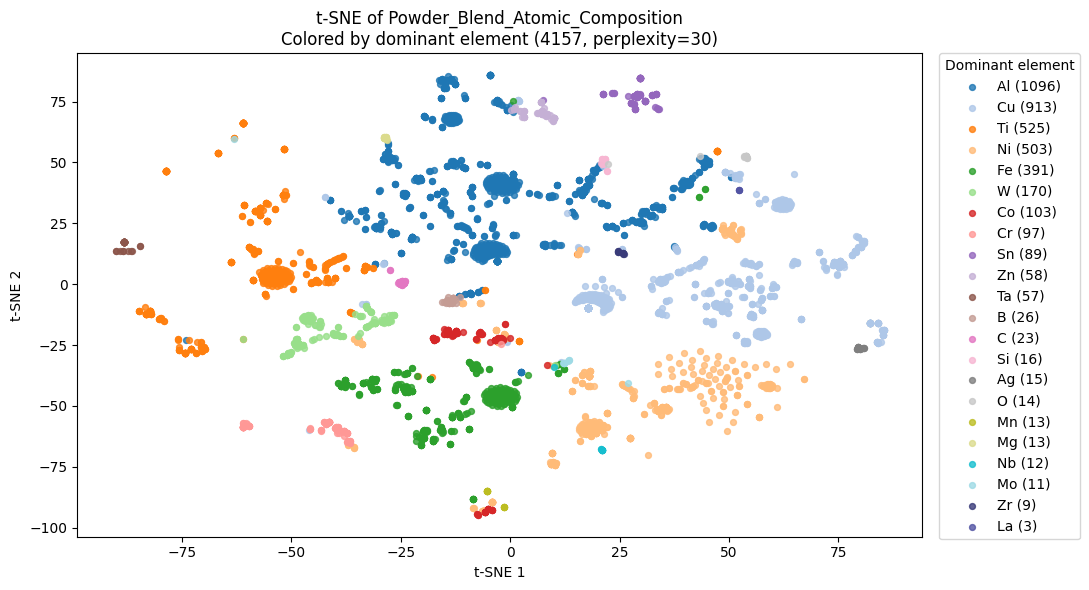

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# -----------------------------
# Path (edit if needed)
# -----------------------------
DATASET_PATH = "../HUGO-CS/Dataset/HUGO-CS.json"

# -----------------------------
# Helpers
# -----------------------------
def _safe_load_extracted_text(extracted):
    if isinstance(extracted, str):
        try:
            return json.loads(extracted)
        except Exception:
            return {}
    return extracted

def _iter_experiments(docs):
    for doc in docs:
        if not isinstance(doc, dict):
            continue
        ext = _safe_load_extracted_text(doc.get("extractedText", {}))
        exps = []
        if isinstance(ext, dict):
            exps = ext.get("Experiments", []) or []
        elif isinstance(ext, list):
            for item in ext:
                if isinstance(item, dict):
                    exps.extend(item.get("Experiments", []) or [])
        for exp in exps:
            if isinstance(exp, dict):
                yield doc.get("filename", ""), exp

def _parse_powder_blend_atomic(comp_str):
    """
    Powder_Blend_Atomic_Composition is stored as a JSON string.
    Returns dict element -> float percentage (missing/blank -> 0.0).
    Keys look like Majority_Powder_Si_Percentage.
    """
    if not isinstance(comp_str, str) or not comp_str.strip():
        return {}

    try:
        d = json.loads(comp_str)
    except Exception:
        return {}

    if not isinstance(d, dict):
        return {}

    out = {}
    prefix = "Majority_Powder_"
    suffix = "_Percentage"

    for k, v in d.items():
        if not isinstance(k, str) or not k.startswith(prefix) or not k.endswith(suffix):
            continue
        el = k[len(prefix):-len(suffix)]  # e.g., "Si", "O", "Other"
        if v in (None, "", "NaN"):
            out[el] = 0.0
        else:
            try:
                out[el] = float(v)
            except Exception:
                out[el] = 0.0
    return out

def _dominant_element(comp: dict) -> str:
    """Returns the element with the largest %; 'Unknown' if all zero/empty."""
    if not isinstance(comp, dict) or not comp:
        return "Unknown"
    items = [(el, float(v)) for el, v in comp.items() if isinstance(v, (int, float)) and float(v) > 0]
    if not items:
        return "Unknown"
    items.sort(key=lambda t: (t[1], t[0]))  # stable tie-break
    return items[-1][0]

def _distinct_paper_colors(n: int):
    """
    Returns n distinct, reasonable colors for papers using Matplotlib qualitative palettes.
    For n=23: uses tab20 (20 colors) + first 3 of tab20b (3 colors).
    """
    tab20  = list(plt.get_cmap("tab20").colors)
    tab20b = list(plt.get_cmap("tab20b").colors)
    tab20c = list(plt.get_cmap("tab20c").colors)
    pool = tab20 + tab20b + tab20c  # plenty of distinct categorical colors
    if n > len(pool):
        raise ValueError(f"Requested {n} colors but only {len(pool)} available in pool.")
    return pool[:n]

# -----------------------------
# Load dataset + build matrix
# -----------------------------
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    docs = json.load(f)

rows = []
for filename, exp in _iter_experiments(docs):
    pre = exp.get("preSprayedProperties", {}) if isinstance(exp.get("preSprayedProperties"), dict) else {}
    comp_str = pre.get("Powder_Blend_Atomic_Composition", "")
    comp = _parse_powder_blend_atomic(comp_str)
    rows.append({
        "filename": filename,
        "comp": comp,
        "sum": float(sum(comp.values())) if comp else 0.0,
    })

df = pd.DataFrame(rows)

# Keep only experiments with any composition signal
df = df[df["sum"] > 0].reset_index(drop=True)
print(f"Experiments total: {len(rows)}")
print(f"Experiments with non-empty Powder_Blend_Atomic_Composition: {len(df)}")

if len(df) == 0:
    raise RuntimeError("No experiments had non-empty Powder_Blend_Atomic_Composition (sum>0).")

# Determine element set (columns)
all_elements = sorted({el for comp in df["comp"] for el in comp.keys()})
if "Other" in all_elements:
    all_elements = [e for e in all_elements if e != "Other"] + ["Other"]

# Build numeric feature matrix
X = np.zeros((len(df), len(all_elements)), dtype=float)
for i, comp in enumerate(df["comp"]):
    for j, el in enumerate(all_elements):
        X[i, j] = float(comp.get(el, 0.0))

# Dominant element labels
df["dominant_element"] = df["comp"].apply(_dominant_element)

# -----------------------------
# t-SNE
# -----------------------------
X_scaled = StandardScaler().fit_transform(X)

perplexity = min(30, max(5, (len(df) - 1) // 3))
coords = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    perplexity=perplexity,
    learning_rate="auto"
).fit_transform(X_scaled)

df_plot = pd.DataFrame({
    "TSNE1": coords[:, 0],
    "TSNE2": coords[:, 1],
    "dominant_element": df["dominant_element"].values
})

# Legend order by frequency (most common first) + counts
counts = df_plot["dominant_element"].value_counts()
order = counts.index.tolist()

# -----------------------------
# Plot (colored by dominant element; 1 unique color per element; legend includes n)
# -----------------------------
N = len(order)
colors = _distinct_paper_colors(N)

plt.figure(figsize=(11, 6))

for i, el in enumerate(order):
    sub = df_plot[df_plot["dominant_element"] == el]
    label = f"{el} ({int(counts[el])})"
    plt.scatter(
        sub["TSNE1"], sub["TSNE2"],
        s=18,
        alpha=0.80,
        label=label,
        color=colors[i]
    )

plt.title(f"t-SNE of Powder_Blend_Atomic_Composition\nColored by dominant element ({len(df_plot)}, perplexity={perplexity})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.legend(
    title="Dominant element",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=True
)

plt.tight_layout()
plt.show()


Loaded 3347 documents.
Pie chart saved to material_name_distribution_pie.png


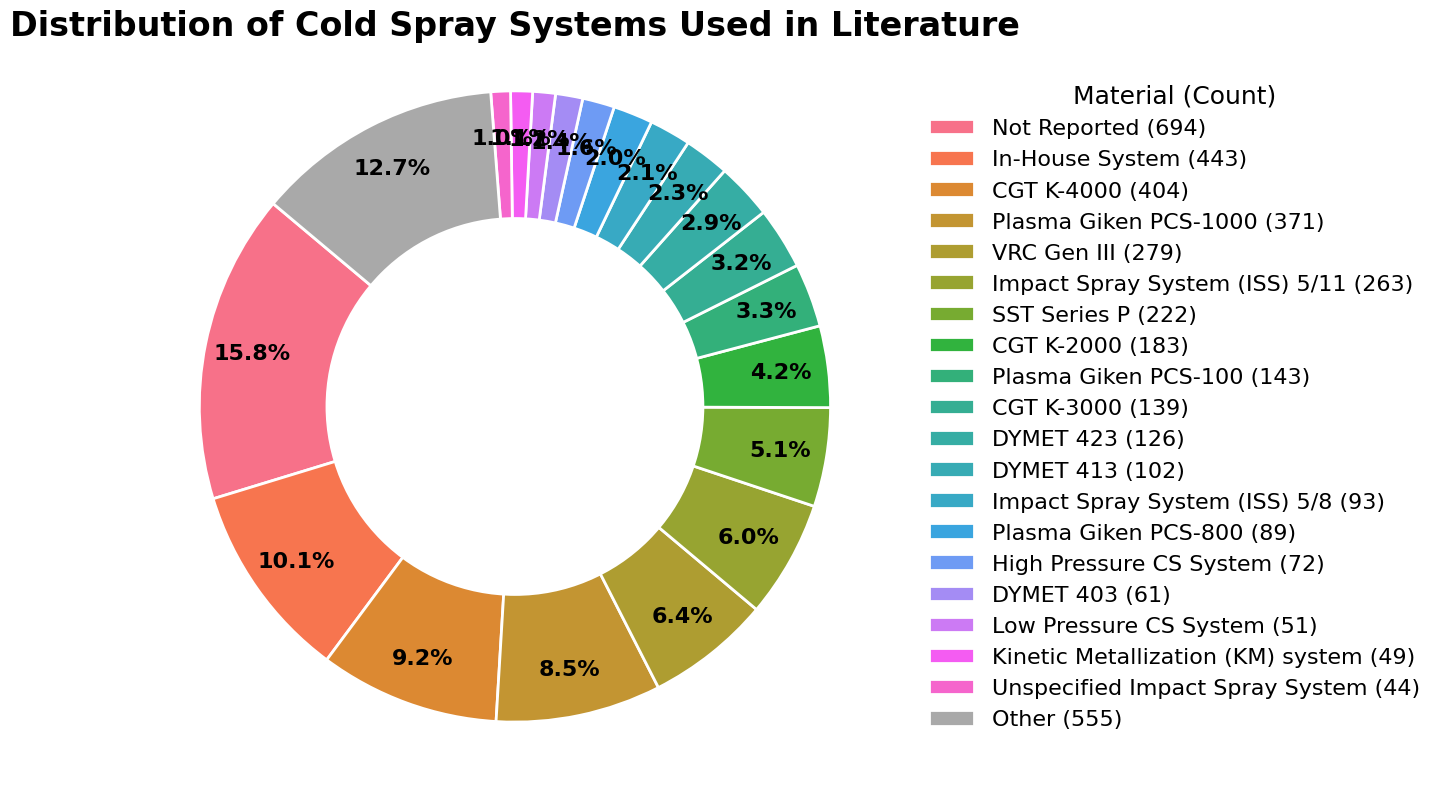

In [14]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Configuration ===
dataset_path = "../HUGO-CS/Dataset/HUGO-CS.json"
output_file = "material_name_distribution_pie.png"
OTHER_THRESHOLD = 0.01

# === Data Extraction ===
try:
    with open(dataset_path, 'r', encoding='utf-8') as f:
        all_docs = json.load(f)
    print(f"Loaded {len(all_docs)} documents.")
except FileNotFoundError:
    print(f"Error: File not found at {dataset_path}")
    all_docs = []

material_counts = {}
for doc in all_docs:
    ext = doc.get("extractedText", {})
    if isinstance(ext, str):
        try:
            ext = json.loads(ext)
        except:
            ext = {}
            
    exps = []
    if isinstance(ext, dict):
        exps = ext.get("Experiments", [])
    elif isinstance(ext, list):
        for item in ext:
            if isinstance(item, dict) and "Experiments" in item:
                exps.extend(item["Experiments"])
                
    if isinstance(exps, list):
        for exp in exps:
            if not isinstance(exp, dict): continue
            props = exp.get("experimentalProperties", {})
            
            # --- CHANGED: Target Material Name instead of Element ---
            val = props.get("Spraying_System_Model", "")
            
            if val and isinstance(val, str):
                val = val.strip()

                # --- NEW: strip "[v] " from start (case-insensitive) ---
                if val.lower().startswith("[v] "):
                    val = val[4:].lstrip()

                # Keep MPC grouping if applicable to names as well
                if val.startswith("MPC:"): val = "MPC (Composite)"
                
                if val: 
                    material_counts[val] = material_counts.get(val, 0) + 1

# === Processing & Plotting ===
if material_counts:
    df = pd.DataFrame(list(material_counts.items()), columns=["Material", "Count"])
    total_count = df["Count"].sum()
    df["Percentage"] = df["Count"] / total_count
    df = df.sort_values("Count", ascending=False)

    if OTHER_THRESHOLD > 0:
        main_df = df[df["Percentage"] >= OTHER_THRESHOLD].copy()
        other_df = df[df["Percentage"] < OTHER_THRESHOLD]
        if not other_df.empty:
            other_count = other_df["Count"].sum()
            new_row = pd.DataFrame([{"Material": "Other", "Count": other_count, "Percentage": other_count/total_count}])
            # Ensure 'Other' is at the end for consistent coloring
            df_plot = pd.concat([main_df, new_row], ignore_index=True)
        else:
            df_plot = main_df
    else:
        df_plot = df

    df_plot["Label"] = df_plot.apply(lambda x: f"{x['Material']} ({x['Count']})", axis=1)

    # === STYLING & COLORS ===
    sns.set_context("poster", font_scale=1.0)
    
    # --- COLOR LOGIC START ---
    # Generate a base palette
    n_colors = len(df_plot)
    palette = sns.color_palette("husl", n_colors) # 'husl' provides distinct colors
    colors = list(palette)

    # The last element is 'Other' (if it exists). The first is the largest category.
    # 'husl' wraps around, so the first and last colors can be similar.
    # Let's explicitly change the last color if it's 'Other'.
    if df_plot.iloc[-1]["Material"] == "Other":
        # Replace the last color with a distinct grey
        colors[-1] = "#A9A9A9" # DarkGray
    # --- COLOR LOGIC END ---

    plt.figure(figsize=(13, 11))
    wedges, texts, autotexts = plt.pie(
        df_plot["Count"], labels=None, autopct='%1.1f%%', startangle=140,
        colors=colors, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_weight('bold')
        autotext.set_fontsize(16)
    
    # Donut chart style
    centre_circle = plt.Circle((0,0),0.60,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title('Distribution of Cold Spray Systems Used in Literature', fontsize=24, weight='bold', y=0.96)
    plt.legend(wedges, df_plot["Label"], title="Material (Count)", loc="center left", 
               bbox_to_anchor=(1, 0, 0.5, 1), fontsize=16, title_fontsize=18, frameon=False)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Pie chart saved to {output_file}")
    plt.show()
else:
    print("No material name data found.")


Loaded 3347 documents.
Plot saved to property_counts_paper_quality.png

DATASET STATISTICS (Total Documents Loaded: 3347)

Total Documents Containing Experiments: 1124

--- Documents with Experiments by Source ---
Hand-Labeled                       : 217
Model: o4-mini, Effort: high       : 907

--- Total Experiments by Source ---
Hand-Labeled                       : 1762
Model: o4-mini, Effort: high       : 2621



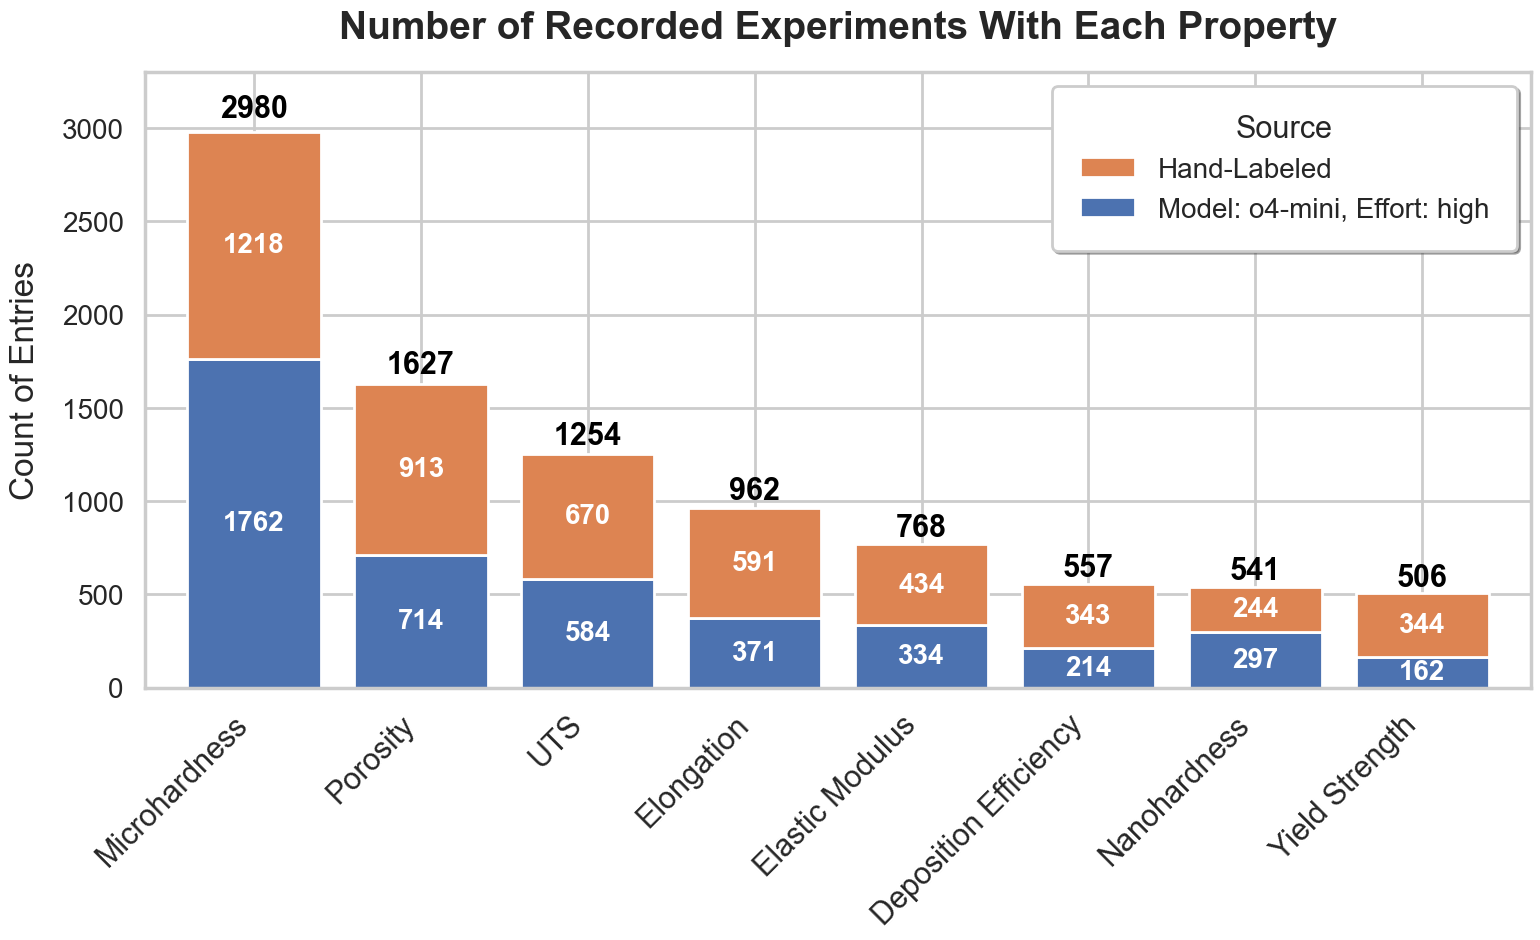

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuration ===
dataset_path = "../HUGO-CS/Dataset/HUGO-CS.json"

feature_map = {
    "Porosity_Value": "Porosity",
    "Elastic_Modulus_Value": "Elastic Modulus",
    "Yield_Strength_Value": "Yield Strength",
    "Ultimate_Tensile_Strength_Value": "UTS",
    "Elongation_at_Break_Value": "Elongation",
    "Deposit_Microhardness_Value": "Microhardness",
    "Deposit_Nanohardness_Value": "Nanohardness",
    "Deposition_Efficiency_Value": "Deposition Efficiency"
}

BOTTOM_SOURCE = "Model: o4-mini, Effort: high"
HAND_LABEL_NAME = "Hand-Labeled"

# === Data Extraction ===
try:
    with open(dataset_path, 'r', encoding='utf-8') as f:
        all_docs = json.load(f)
    print(f"Loaded {len(all_docs)} documents.")
except FileNotFoundError:
    print(f"Error: File not found at {dataset_path}")
    all_docs = []

records = []
source_experiment_counts = {}  # Tracks total experiments per source
source_doc_with_exp_counts = {} # Tracks documents WITH experiments per source
docs_with_experiments_count = 0 # Tracks global count of docs that actually had experiments

for doc in all_docs:
    raw_source = doc.get("InformationSource", "Unknown")
    
    # Merge Ground Truths
    if "Ground Truth" in raw_source:
        source = HAND_LABEL_NAME
    else:
        source = raw_source

    ext = doc.get("extractedText", {})
    if isinstance(ext, str):
        try:
            ext = json.loads(ext)
        except:
            ext = {}

    exps = []
    if isinstance(ext, dict):
        exps = ext.get("Experiments", [])
    elif isinstance(ext, list):
        for item in ext:
            if isinstance(item, dict) and "Experiments" in item:
                exps.extend(item["Experiments"])

    # Only process if experiments exist
    if isinstance(exps, list) and len(exps) > 0:
        # <--- NEW: Count Docs with Experiments (Global & Per Source) ---
        docs_with_experiments_count += 1
        source_doc_with_exp_counts[source] = source_doc_with_exp_counts.get(source, 0) + 1
        
        # Count total experiments for this source
        current_count = len(exps)
        source_experiment_counts[source] = source_experiment_counts.get(source, 0) + current_count
        
        for exp in exps:
            if not isinstance(exp, dict): continue
            res = exp.get("resultsValues", {})
            for key in feature_map.keys():
                val = res.get(key, "")
                if val not in (None, "", []):
                    records.append({
                        "Feature": key,
                        "Source": source
                    })

# === Processing & Plotting ===
if records:
    df = pd.DataFrame(records)
    
    # Pivot
    counts = df.groupby(["Feature", "Source"]).size().unstack(fill_value=0)
    
    # Remap Index
    counts.index = counts.index.map(feature_map)
    
    # Sort by Total
    counts["Total"] = counts.sum(axis=1)
    counts = counts.sort_values("Total", ascending=False)
    # Save totals for the top labels, then drop column
    totals = counts["Total"] 
    counts = counts.drop(columns="Total")

    # Stack Ordering
    cols = list(counts.columns)
    if BOTTOM_SOURCE in cols:
        cols.remove(BOTTOM_SOURCE)
    remaining = sorted(cols)
    ordered_cols = [BOTTOM_SOURCE] + remaining if BOTTOM_SOURCE in counts.columns else remaining
    counts = counts[ordered_cols]

    # === STYLING ===
    # "poster" context scales all fonts up significantly for papers/posters
    sns.set_context("poster", font_scale=1.1)
    sns.set_style("whitegrid")
    
    # Professional Palette
    custom_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
    
    fig, ax = plt.subplots(figsize=(16, 10))

    counts.plot(
        kind='bar', 
        stacked=True, 
        color=custom_colors[:len(counts.columns)],
        edgecolor='white',
        width=0.8,
        ax=ax
    )

    # 1. Add numbers inside the bar segments
    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in container]
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='center', 
            fontsize=20, # Big font for inside numbers
            color='white', 
            weight='bold'
        )

    # 2. Add TOTAL sum on top of each bar
    for i, total in enumerate(totals):
        ax.text(
            x=i, 
            y=total + (total * 0.015), # Slight offset above bar
            s=f'{int(total)}', 
            ha='center', 
            va='bottom', 
            fontsize=22, 
            weight='bold',
            color='black'
        )

    # Labels and Titles
    plt.title('Number of Recorded Experiments With Each Property', fontsize=28, weight='bold', pad=25)
    plt.ylabel('Count of Entries', fontsize=24, labelpad=15)
    plt.xlabel('', fontsize=24)
    plt.xticks(rotation=45, ha='right', fontsize=22)
    plt.yticks(fontsize=20)
    plt.ylim(0, 3300)

    # Legend - Upper Right, Larger Font
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1], 
        labels[::-1], 
        title='Source', 
        title_fontsize=22, 
        fontsize=20, 
        loc='upper right',
        frameon=True,
        shadow=True,
        borderpad=1  # Adds breathing room inside legend box
    )

    plt.tight_layout()
    output_file = "property_counts_paper_quality.png"
    plt.savefig(output_file, dpi=300)
    print(f"Plot saved to {output_file}")

    # <--- NEW: Print Statistics --->
    print("\n" + "="*50)
    print(f"DATASET STATISTICS (Total Documents Loaded: {len(all_docs)})")
    print("="*50)
    
    print(f"\nTotal Documents Containing Experiments: {docs_with_experiments_count}")
    
    print("\n--- Documents with Experiments by Source ---")
    for source_name in sorted(source_doc_with_exp_counts.keys()):
        count = source_doc_with_exp_counts[source_name]
        print(f"{source_name:<35}: {count}")

    print("\n--- Total Experiments by Source ---")
    for source_name in sorted(source_experiment_counts.keys()):
        count = source_experiment_counts[source_name]
        print(f"{source_name:<35}: {count}")
    print("="*50 + "\n")

    plt.show()

else:
    print("No data found.")

Loaded 1124 documents.
Plot saved to property_counts_paper_quality.png

DATASET STATISTICS (Total Documents Loaded: 1124)

Total Documents Containing Experiments: 1124

--- Documents with Experiments by Source ---
Hand-Labeled                       : 217
Model: o4-mini, Effort: high       : 907

--- Total Experiments by Source ---
Hand-Labeled                       : 1762
Model: o4-mini, Effort: high       : 2621



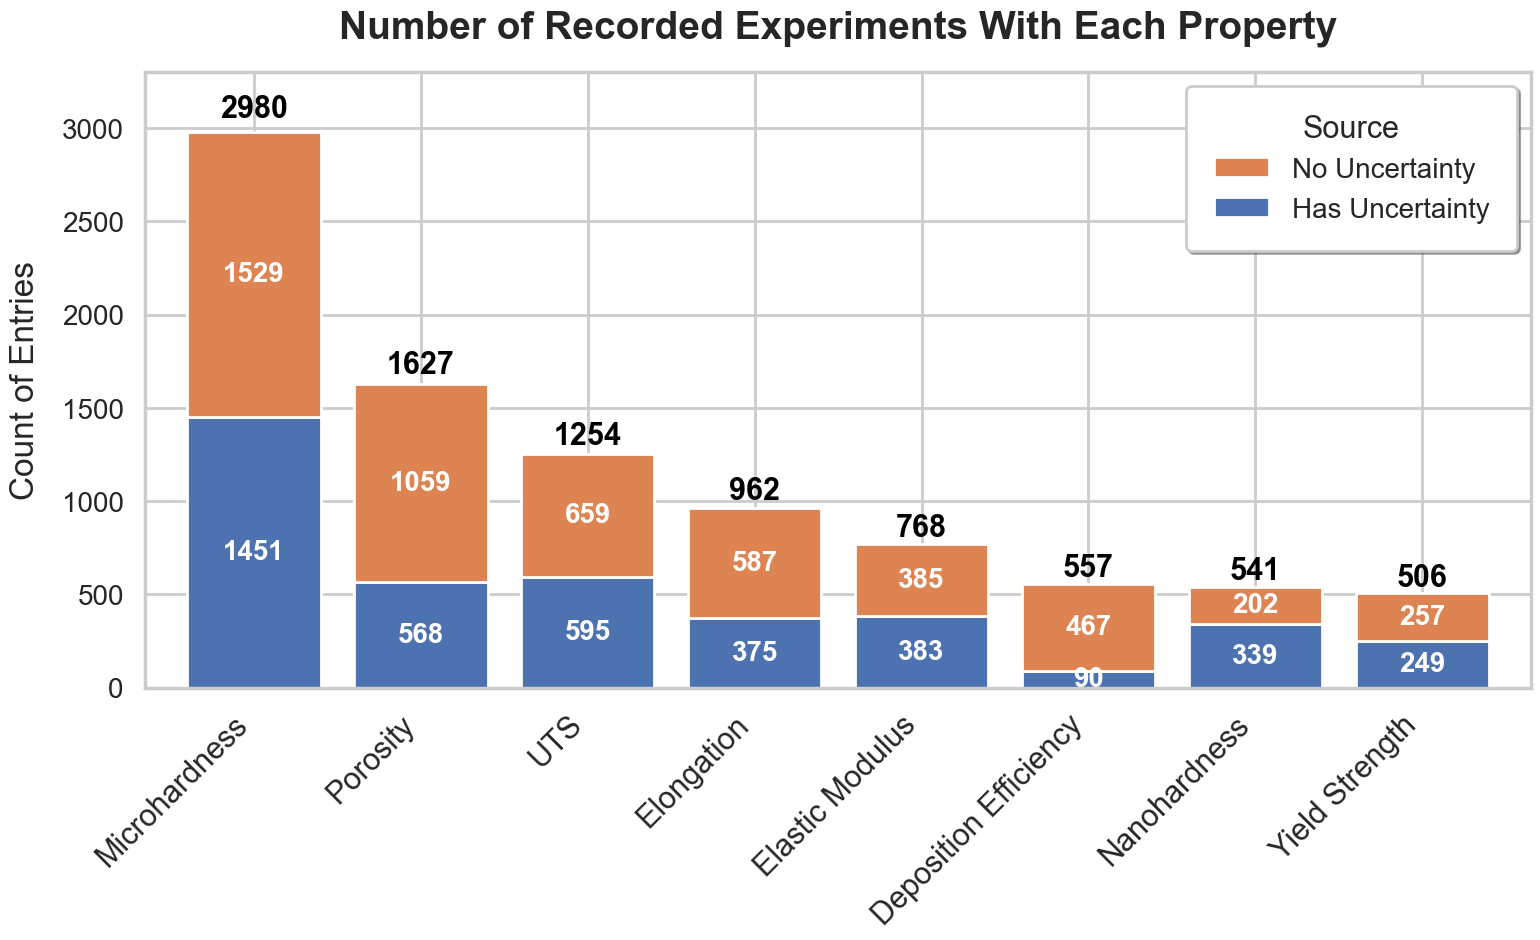

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuration ===
dataset_path = "../HUGO-CS/Dataset/AlternateVersions/Extracted-6-10-25_gt_remapped_swapped_deleted_filled_sorted_powderClass_grouped_imputed_blended_treatment_standardized.json"

feature_map = {
    "Porosity_Value": "Porosity",
    "Elastic_Modulus_Value": "Elastic Modulus",
    "Yield_Strength_Value": "Yield Strength",
    "Ultimate_Tensile_Strength_Value": "UTS",
    "Elongation_at_Break_Value": "Elongation",
    "Deposit_Microhardness_Value": "Microhardness",
    "Deposit_Nanohardness_Value": "Nanohardness",
    "Deposition_Efficiency_Value": "Deposition Efficiency"
}

BOTTOM_SOURCE = "Model: o4-mini, Effort: high"
HAND_LABEL_NAME = "Hand-Labeled"

# === Data Extraction ===
try:
    with open(dataset_path, 'r', encoding='utf-8') as f:
        all_docs = json.load(f)
    print(f"Loaded {len(all_docs)} documents.")
except FileNotFoundError:
    print(f"Error: File not found at {dataset_path}")
    all_docs = []

records = []
source_experiment_counts = {}  # Tracks total experiments per source
source_doc_with_exp_counts = {} # Tracks documents WITH experiments per source
docs_with_experiments_count = 0 # Tracks global count of docs that actually had experiments

for doc in all_docs:
    raw_source = doc.get("InformationSource", "Unknown")
    
    # Merge Ground Truths
    if "Ground Truth" in raw_source:
        source = HAND_LABEL_NAME
    else:
        source = raw_source

    ext = doc.get("extractedText", {})
    if isinstance(ext, str):
        try:
            ext = json.loads(ext)
        except:
            ext = {}

    exps = []
    if isinstance(ext, dict):
        exps = ext.get("Experiments", [])
    elif isinstance(ext, list):
        for item in ext:
            if isinstance(item, dict) and "Experiments" in item:
                exps.extend(item["Experiments"])

    # Only process if experiments exist
    if isinstance(exps, list) and len(exps) > 0:
        # <--- NEW: Count Docs with Experiments (Global & Per Source) ---
        docs_with_experiments_count += 1
        source_doc_with_exp_counts[source] = source_doc_with_exp_counts.get(source, 0) + 1
        
        # Count total experiments for this source
        current_count = len(exps)
        source_experiment_counts[source] = source_experiment_counts.get(source, 0) + current_count
        
        for exp in exps:
            if not isinstance(exp, dict): continue
            res = exp.get("resultsValues", {})
            for key in feature_map.keys():
                val = res.get(key, "")
                if val not in (None, "", []):
                    u_key = key.replace("_Value", "_Uncertainty")
                    u_val = res.get(u_key, "")
                    if u_val not in (None, "", []):
                        records.append({
                            "Feature": key,
                            "Source": "Has Uncertainty"
                        })
                    else:
                        records.append({
                            "Feature": key,
                            "Source": "No Uncertainty"
                        })

# === Processing & Plotting ===
if records:
    df = pd.DataFrame(records)
    
    # Pivot
    counts = df.groupby(["Feature", "Source"]).size().unstack(fill_value=0)
    
    # Remap Index
    counts.index = counts.index.map(feature_map)
    
    # Sort by Total
    counts["Total"] = counts.sum(axis=1)
    counts = counts.sort_values("Total", ascending=False)
    # Save totals for the top labels, then drop column
    totals = counts["Total"] 
    counts = counts.drop(columns="Total")

    # Stack Ordering
    cols = list(counts.columns)
    if BOTTOM_SOURCE in cols:
        cols.remove(BOTTOM_SOURCE)
    remaining = sorted(cols)
    ordered_cols = [BOTTOM_SOURCE] + remaining if BOTTOM_SOURCE in counts.columns else remaining
    counts = counts[ordered_cols]

    # === STYLING ===
    # "poster" context scales all fonts up significantly for papers/posters
    sns.set_context("poster", font_scale=1.1)
    sns.set_style("whitegrid")
    
    # Professional Palette
    custom_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
    
    fig, ax = plt.subplots(figsize=(16, 10))

    counts.plot(
        kind='bar', 
        stacked=True, 
        color=custom_colors[:len(counts.columns)],
        edgecolor='white',
        width=0.8,
        ax=ax
    )

    # 1. Add numbers inside the bar segments
    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in container]
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='center', 
            fontsize=20, # Big font for inside numbers
            color='white', 
            weight='bold'
        )

    # 2. Add TOTAL sum on top of each bar
    for i, total in enumerate(totals):
        ax.text(
            x=i, 
            y=total + (total * 0.015), # Slight offset above bar
            s=f'{int(total)}', 
            ha='center', 
            va='bottom', 
            fontsize=22, 
            weight='bold',
            color='black'
        )

    # Labels and Titles
    plt.title('Number of Recorded Experiments With Each Property', fontsize=28, weight='bold', pad=25)
    plt.ylabel('Count of Entries', fontsize=24, labelpad=15)
    plt.xlabel('', fontsize=24)
    plt.xticks(rotation=45, ha='right', fontsize=22)
    plt.yticks(fontsize=20)
    plt.ylim(0, 3300)

    # Legend - Upper Right, Larger Font
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1], 
        labels[::-1], 
        title='Source', 
        title_fontsize=22, 
        fontsize=20, 
        loc='upper right',
        frameon=True,
        shadow=True,
        borderpad=1  # Adds breathing room inside legend box
    )

    plt.tight_layout()
    output_file = "property_counts_paper_quality.png"
    plt.savefig(output_file, dpi=300)
    print(f"Plot saved to {output_file}")

    # <--- NEW: Print Statistics --->
    print("\n" + "="*50)
    print(f"DATASET STATISTICS (Total Documents Loaded: {len(all_docs)})")
    print("="*50)
    
    print(f"\nTotal Documents Containing Experiments: {docs_with_experiments_count}")
    
    print("\n--- Documents with Experiments by Source ---")
    for source_name in sorted(source_doc_with_exp_counts.keys()):
        count = source_doc_with_exp_counts[source_name]
        print(f"{source_name:<35}: {count}")

    print("\n--- Total Experiments by Source ---")
    for source_name in sorted(source_experiment_counts.keys()):
        count = source_experiment_counts[source_name]
        print(f"{source_name:<35}: {count}")
    print("="*50 + "\n")

    plt.show()

else:
    print("No data found.")

In [5]:
import os

def print_ev_wev_for_article_id(article_id: int) -> None:
    """
    Prints ONLY:
      - EV (per metric)  = X[m] already computed in your V(D) block
      - wEV (per metric) = w[m] * EV
      - Total EV, Total wEV (= V(D))
    Requires that your V(D) calculation has already run and created:
      pre_docs, per_doc, w, V_map
    """
    target_base = f"Article_{int(article_id)}.md"

    # Find the matching doc by basename (robust to paths)
    doc = next(
        (d for d in pre_docs if os.path.basename(d.get("filename", "")) == target_base),
        None
    )
    if doc is None:
        print(f"[ERROR] Could not find {target_base!r} in pre_docs.")
        return

    # per_doc in your V(D) calc is keyed by d.get("filename") (could include paths),
    # so try both full and basename.
    fname_full = doc.get("filename", target_base)
    info = per_doc.get(fname_full) or per_doc.get(target_base)

    if not info:
        print(f"[ERROR] No EV/X entry found for {target_base!r}. "
              f"This usually means it wasn't included in cat2 with properties_reported_in_figures.")
        return

    X = info.get("X", {})   # EVs per metric (already max(0, E - r))
    M = info.get("M", [])   # metrics considered for this doc

    print("=" * 70)
    print(f"{target_base}")
    print("-" * 70)
    print(f"{'metric':<28}{'EV':>10}{'wEV':>14}")
    print("-" * 70)

    total_ev = 0.0
    total_wev = 0.0

    for m in M:
        ev = float(X.get(m, 0.0))
        wev = float(w.get(m, 0.0)) * ev
        total_ev += ev
        total_wev += wev
        print(f"{m:<28}{ev:>10.3f}{wev:>14.6f}")

    Vd = float(V_map.get(fname_full, V_map.get(target_base, 0.0)))

    print("-" * 70)
    print(f"{'TOTAL':<28}{total_ev:>10.3f}{total_wev:>14.6f}")
    print(f"V(D) (from V_map): {Vd:.6f}")
    print("=" * 70)


# Example:
print_ev_wev_for_article_id(2191)

Article_2191.md
----------------------------------------------------------------------
metric                              EV           wEV
----------------------------------------------------------------------
microhardness                    7.000      0.096623
----------------------------------------------------------------------
TOTAL                            7.000      0.096623
V(D) (from V_map): 0.096623


In [9]:
import json
import re
from pathlib import Path
from collections import Counter
from typing import Any, Dict, List, Tuple, Set

# -----------------------------
# Paths
# -----------------------------
EXP_JSON_PATH = "../HUGO-CS/Dataset/AlternateVersions/Extracted-6-10-25_gt_remapped_swapped_deleted_filled_sorted.json"
REPLACE_JSON_PATH = "../HUGO-CS/prompts/regExReplace2.json"

_WS_RE = re.compile(r"\s+")

def load_json(path: str) -> Any:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def norm_key(s: str) -> str:
    """Case-insensitive, whitespace-normalized key."""
    return _WS_RE.sub(" ", s.strip()).lower()

def safe_load_extracted_text(extracted: Any) -> Any:
    """Handle extractedText being dict, list, or JSON string."""
    if isinstance(extracted, str):
        try:
            return json.loads(extracted)
        except json.JSONDecodeError:
            return {}
    return extracted

def flatten_experiments_from_articles(articles: Any) -> List[Dict[str, Any]]:
    all_exps: List[Dict[str, Any]] = []
    if not isinstance(articles, list):
        return all_exps

    for art in articles:
        if not isinstance(art, dict):
            continue
        extracted = safe_load_extracted_text(art.get("extractedText", {}))

        exps: List[Any] = []
        if isinstance(extracted, dict):
            exps = extracted.get("Experiments", []) or []
        elif isinstance(extracted, list):
            for item in extracted:
                if isinstance(item, dict):
                    exps.extend(item.get("Experiments", []) or [])

        for exp in exps:
            if isinstance(exp, dict):
                all_exps.append(exp)

    return all_exps

def collect_feature_strings(
    experiments: List[Dict[str, Any]],
    section: str,
    feature: str
) -> List[str]:
    """Collect all string values (including repeats) for a given feature."""
    vals: List[str] = []
    for exp in experiments:
        props = exp.get(section, {})
        if not isinstance(props, dict):
            continue
        v = props.get(feature)
        if isinstance(v, str) and v.strip():
            vals.append(v)
    return vals

def invert_replace_map(replace_map: Dict[str, Any]) -> Dict[str, Set[str]]:
    """
    Build: canonical_repr -> { normalized_raw_key, ... }
    Note: we use repr(canonical) to match your earlier pipeline conventions.
    """
    inv: Dict[str, Set[str]] = {}
    for raw_key, canon in (replace_map or {}).items():
        if not isinstance(raw_key, str):
            continue
        canon_repr = repr(canon)
        inv.setdefault(canon_repr, set()).add(norm_key(raw_key))
    return inv

def audit_specific_canonical(
    experiments: List[Dict[str, Any]],
    replace_dict: Dict[str, Any],
    mapping_key: str,
    canonical_target: str,
    *,
    section: str = "preSprayedProperties",
    features: List[str] = None
) -> Dict[str, Any]:
    """
    For a specific canonical_target (string, e.g. "[V] Al 6061"),
    report how many unique raw strings observed in each feature map to it,
    plus totals and the actual raw strings.
    """
    if features is None:
        features = [
            "Majority_Powder_Material_Name",
            "Secondary_Powder_Material_Name",
            "Tertiary_Powder_Material_Name",
        ]

    replace_map = (replace_dict or {}).get(mapping_key, {}) or {}
    inv = invert_replace_map(replace_map)

    # canonical_target is already a string like "[V] Al 6061"
    # BUT your pipeline stores canonical as repr(value), so we must compare to repr(canon)
    target_repr = repr(canonical_target)

    valid_norm_keys = inv.get(target_repr, set())

    out: Dict[str, Any] = {
        "mapping_key": mapping_key,
        "canonical_target": canonical_target,
        "canonical_target_repr": target_repr,
        "features": {},
        "combined": {},
    }

    combined_unique_raw: Set[str] = set()
    combined_total_occ = 0

    for feat in features:
        observed_vals = collect_feature_strings(experiments, section, feat)
        counts = Counter(observed_vals)

        # Keep only raw strings whose normalized form is in the set that maps to the target canonical
        mapped_raw_unique = [raw for raw in counts.keys() if norm_key(raw) in valid_norm_keys]
        mapped_raw_unique.sort(key=lambda s: (s.casefold(), s))

        total_mapped_occ = sum(counts[raw] for raw in mapped_raw_unique)

        out["features"][feat] = {
            "total_observed_occurrences": len(observed_vals),
            "unique_observed_strings": len(counts),
            "unique_raw_strings_mapped_to_target": len(mapped_raw_unique),
            "total_occurrences_mapped_to_target": total_mapped_occ,
            "mapped_raw_strings": mapped_raw_unique,
            "mapped_raw_strings_with_counts": [(raw, counts[raw]) for raw in mapped_raw_unique],
        }

        combined_unique_raw.update(mapped_raw_unique)
        combined_total_occ += total_mapped_occ

    combined_unique_sorted = sorted(combined_unique_raw, key=lambda s: (s.casefold(), s))

    out["combined"] = {
        "unique_raw_strings_mapped_to_target_across_all_three": len(combined_unique_sorted),
        "total_occurrences_mapped_to_target_across_all_three": combined_total_occ,
        "mapped_raw_strings_across_all_three": combined_unique_sorted,
    }

    return out

def print_specific_canonical_report(report: Dict[str, Any]) -> None:
    print(f"=== Canonical target audit ===")
    print(f"Mapping key:        {report['mapping_key']}")
    print(f"Canonical target:   {report['canonical_target']!r}")
    print(f"(Internal repr):    {report['canonical_target_repr']!r}")
    print()

    for feat, r in report["features"].items():
        print(f"-- {feat} --")
        print(f"Total observed occurrences:           {r['total_observed_occurrences']}")
        print(f"Unique observed strings:              {r['unique_observed_strings']}")
        print(f"Unique raw strings mapped to target:  {r['unique_raw_strings_mapped_to_target']}")
        print(f"Total occurrences mapped to target:   {r['total_occurrences_mapped_to_target']}")
        if r["unique_raw_strings_mapped_to_target"] > 0:
            print("Mapped raw strings (with counts):")
            for raw, cnt in r["mapped_raw_strings_with_counts"]:
                print(f"  - {raw!r} (n={cnt})")
        print()

    c = report["combined"]
    print("== Combined across Majority/Secondary/Tertiary ==")
    print(f"Unique raw strings mapped to target:  {c['unique_raw_strings_mapped_to_target_across_all_three']}")
    print(f"Total occurrences mapped to target:   {c['total_occurrences_mapped_to_target_across_all_three']}")
    if c["unique_raw_strings_mapped_to_target_across_all_three"] > 0:
        print("Unique raw strings across all three:")
        for raw in c["mapped_raw_strings_across_all_three"]:
            print(f"  - {raw!r}")

articles = load_json(EXP_JSON_PATH)
replace_dict = load_json(REPLACE_JSON_PATH)
experiments = flatten_experiments_from_articles(articles)

report = audit_specific_canonical(
    experiments,
    replace_dict,
    mapping_key="materialNamingConventions",
    canonical_target="[V] Pure Al",
)

print_specific_canonical_report(report)

=== Canonical target audit ===
Mapping key:        materialNamingConventions
Canonical target:   '[V] Pure Al'
(Internal repr):    "'[V] Pure Al'"

-- Majority_Powder_Material_Name --
Total observed occurrences:           4383
Unique observed strings:              680
Unique raw strings mapped to target:  44
Total occurrences mapped to target:   488
Mapped raw strings (with counts):
  - '1100 Al' (n=2)
  - '99.5% Al' (n=25)
  - 'AA 1080 aluminum' (n=2)
  - 'AA1050 Al' (n=1)
  - 'Al' (n=124)
  - 'Al (purity≥ 99.83%)' (n=3)
  - 'Al 99.5%' (n=6)
  - 'Al H-10' (n=3)
  - 'Al powder' (n=21)
  - 'Al1050' (n=1)
  - 'Al99.0' (n=2)
  - 'Aluminium' (n=8)
  - 'Aluminium powder' (n=6)
  - 'Aluminum' (n=73)
  - 'Aluminum (ASD-1 grade)' (n=3)
  - 'Aluminum (Ecka Al AS081)' (n=4)
  - 'Aluminum (H3)' (n=4)
  - 'Aluminum H3' (n=3)
  - 'Aluminum powder' (n=12)
  - 'Brodmann Flomaster' (n=2)
  - 'Commercially Pure Al' (n=2)
  - 'Commercially pure Al' (n=5)
  - 'Commercially Pure Al (A5001)' (n=2)
  - 'Com

In [ ]:
import json
import re
from collections import Counter, defaultdict
from typing import Any, Dict, List, Set, Tuple

# -----------------------------
# Paths
# -----------------------------
EXP_JSON_PATH = "../HUGO-CS/Dataset/AlternateVersions/Extracted-6-10-25_gt_remapped_swapped_deleted_filled_sorted.json"
REPLACE_JSON_PATH = "../HUGO-CS/prompts/regExReplace2.json"

# -----------------------------
# Helpers (same conventions as before)
# -----------------------------
_WS_RE = re.compile(r"\s+")

def load_json(path: str) -> Any:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def norm_key(s: str) -> str:
    return _WS_RE.sub(" ", s.strip()).lower()

def safe_load_extracted_text(extracted: Any) -> Any:
    if isinstance(extracted, str):
        try:
            return json.loads(extracted)
        except json.JSONDecodeError:
            return {}
    return extracted

def flatten_experiments_from_articles(articles: Any) -> List[Dict[str, Any]]:
    all_exps: List[Dict[str, Any]] = []
    if not isinstance(articles, list):
        return all_exps

    for art in articles:
        if not isinstance(art, dict):
            continue
        extracted = safe_load_extracted_text(art.get("extractedText", {}))

        exps: List[Any] = []
        if isinstance(extracted, dict):
            exps = extracted.get("Experiments", []) or []
        elif isinstance(extracted, list):
            for item in extracted:
                if isinstance(item, dict):
                    exps.extend(item.get("Experiments", []) or [])

        for exp in exps:
            if isinstance(exp, dict):
                all_exps.append(exp)

    return all_exps

def collect_feature_strings(experiments: List[Dict[str, Any]], section: str, feature: str) -> List[str]:
    vals: List[str] = []
    for exp in experiments:
        props = exp.get(section, {})
        if not isinstance(props, dict):
            continue
        v = props.get(feature)
        if isinstance(v, str) and v.strip():
            vals.append(v)
    return vals

def invert_replace_map(replace_map: Dict[str, Any]) -> Dict[str, Set[str]]:
    """
    canonical_repr -> set(normalized_raw_key)
    Mirrors prior convention: canonical stored/compared via repr(...)
    """
    inv: Dict[str, Set[str]] = {}
    for raw_key, canon in (replace_map or {}).items():
        if not isinstance(raw_key, str):
            continue
        canon_repr = repr(canon)
        inv.setdefault(canon_repr, set()).add(norm_key(raw_key))
    return inv

# -----------------------------
# Main: compute top-15 canonicals by unique raw strings observed mapping to them
# -----------------------------
SECTION = "preSprayedProperties"
FEATURES = [
    "Majority_Powder_Material_Name",
    "Secondary_Powder_Material_Name",
    "Tertiary_Powder_Material_Name",
]
MAPPING_KEY = "materialNamingConventions"
TOP_K = 15

articles = load_json(EXP_JSON_PATH)
replace_dict = load_json(REPLACE_JSON_PATH)
experiments = flatten_experiments_from_articles(articles)

replace_map = (replace_dict or {}).get(MAPPING_KEY, {}) or {}
inv = invert_replace_map(replace_map)  # canonical_repr -> normalized raw keys

# For each canonical, track unique *observed* raw strings that map to it (and occurrence totals)
canon_to_unique_raw_observed: Dict[str, Set[str]] = defaultdict(set)
canon_to_total_occ: Dict[str, int] = defaultdict(int)

# Precompute norm_raw_key -> canonical_repr for fast lookup
norm_raw_to_canon: Dict[str, str] = {}
for raw_key, canon in replace_map.items():
    if isinstance(raw_key, str):
        norm_raw_to_canon[norm_key(raw_key)] = repr(canon)

# Scan all observed values across the three material features
for feat in FEATURES:
    observed_vals = collect_feature_strings(experiments, SECTION, feat)
    counts = Counter(observed_vals)

    for raw, cnt in counts.items():
        nk = norm_key(raw)
        canon_repr = norm_raw_to_canon.get(nk)
        if canon_repr is None:
            continue  # not mapped by the replace rules
        canon_to_unique_raw_observed[canon_repr].add(raw)
        canon_to_total_occ[canon_repr] += cnt

# Rank canonicals by number of unique observed raw strings mapping to them (desc),
# tie-break by total occurrences (desc), then by canonical label (asc)
ranked: List[Tuple[str, int, int]] = []
for canon_repr, raw_set in canon_to_unique_raw_observed.items():
    ranked.append((canon_repr, len(raw_set), canon_to_total_occ.get(canon_repr, 0)))

ranked.sort(key=lambda x: (-x[1], -x[2], x[0].casefold(), x[0]))

print(f"=== Top {TOP_K} canonical material labels by unique mapped raw strings (observed) ===")
print(f"Section: {SECTION}")
print(f"Features: {FEATURES}")
print(f"Mapping key: {MAPPING_KEY}")
print()

for i, (canon_repr, uniq_ct, total_occ) in enumerate(ranked[:TOP_K], start=1):
    # canon_repr is repr(canon); for display, try to recover the string value (if it is a repr of a string)
    try:
        canon_display = eval(canon_repr, {"__builtins__": {}})  # safe-ish for simple string repr
        if not isinstance(canon_display, str):
            canon_display = canon_repr
    except Exception:
        canon_display = canon_repr

    print(f"{i:>2}. {canon_display!r}")
    print(f"    unique raw strings mapped: {uniq_ct}")
    print(f"    total occurrences mapped:  {total_occ}")

    # Show a short preview of the raw variants
    raw_variants = sorted(canon_to_unique_raw_observed[canon_repr], key=lambda s: (s.casefold(), s))
    preview = raw_variants[:12]
    for rv in preview:
        print(f"      - {rv!r}")
    if len(raw_variants) > len(preview):
        print(f"      - ... ({len(raw_variants) - len(preview)} more)")
    print()

=== Top 15 canonical material labels by unique mapped raw strings (observed) ===
Section: preSprayedProperties
Features: ['Majority_Powder_Material_Name', 'Secondary_Powder_Material_Name', 'Tertiary_Powder_Material_Name']
Mapping key: materialNamingConventions

 1. '[V] Pure Cu'
    unique raw strings mapped: 53
    total occurrences mapped:  757
      - '500A Copper'
      - 'Acupowder 500'
      - 'Commercially pure copper'
      - 'Commercially pure copper powder'
      - 'Commercially spherical Cu powder'
      - 'Conventional Cu'
      - 'Copper'
      - 'Copper (Cu)'
      - 'Copper (dendritic)'
      - 'Copper (PMS-1 grade)'
      - 'Copper (spherical)'
      - 'Copper PMS-1'
      - ... (41 more)

 2. '[V] Pure Al'
    unique raw strings mapped: 46
    total occurrences mapped:  599
      - '1100 Al'
      - '99.5% Al'
      - 'AA 1080 aluminum'
      - 'AA1050 Al'
      - 'Al'
      - 'Al (purity≥ 99.83%)'
      - 'Al 99.5%'
      - 'Al H-10'
      - 'Al micron powder'
      -